In [ ]:
# ==========================================
# 1. IMPORT REQUIRED LIBRARIES
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# ==========================================
# 2. LOAD THE DATASET
# ==========================================
df = pd.read_csv("spam.csv", encoding="latin-1")
# Keeping only the relevant columns and renaming them
df = df[["v1", "v2"]]
df.columns = ["label", "message"]

print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


In [ ]:
# ==========================================
# 3. CHECK DATASET INFORMATION
# ==========================================
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nEmail Message Counts:")
print(df["label"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Missing Values:
label      0
message    0
dtype: int64

Email Message Counts:
label
ham     4825
spam     747
Name: count, dtype: int64


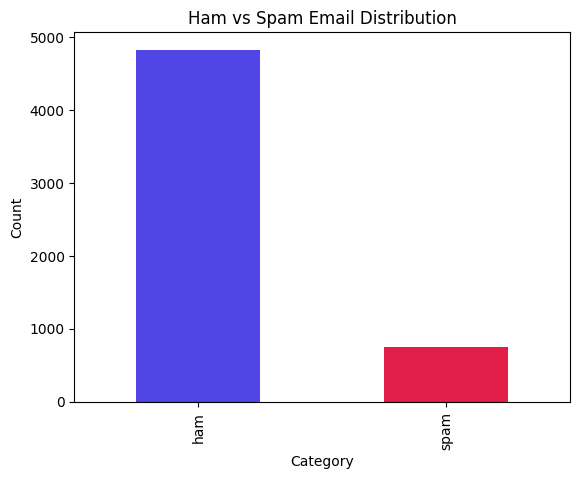

In [ ]:
# Visualize class distribution
df["label"].value_counts().plot(kind="bar", color=["#4f46e5", "#e11d48"])
plt.title("Ham vs Spam Email Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [ ]:
# ==========================================
# 4. PREPARE INPUT AND OUTPUT
# ==========================================
X = df["message"]
y = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Input Shape:", X.shape)
print("Output Shape:", y.shape)

Input Shape: (5572,)
Output Shape: (5572,)


In [ ]:
# Train-Test Split (80:20 Stratified Split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (4457,)
Testing Data: (1115,)


In [ ]:
# ==========================================
# 5. BUILD THE PIPELINE & TRAIN MODEL
# ==========================================
model = make_pipeline(
    TfidfVectorizer(stop_words="english", lowercase=True),
    MultinomialNB()
)

model.fit(X_train, y_train)
print("Model Training Completed!")

Model Training Completed!


In [ ]:
# ==========================================
# 6. MAKE PREDICTIONS & EVALUATE
# ==========================================
y_pred = model.predict(X_test)

print("Model Accuracy:", accuracy_score(y_test, y_pred) * 100, "%")

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Legitimate (Ham)", "Spam"]
))

Model Accuracy: 96.8609865470852 %

Classification Report:
                  precision    recall  f1-score   support

Legitimate (Ham)       0.97      1.00      0.98       966
            Spam       1.00      0.77      0.87       149

        accuracy                           0.97      1115
       macro avg       0.98      0.88      0.92      1115
    weighted avg       0.97      0.97      0.97      1115



Confusion Matrix:
 [[966   0]
 [ 35 114]]


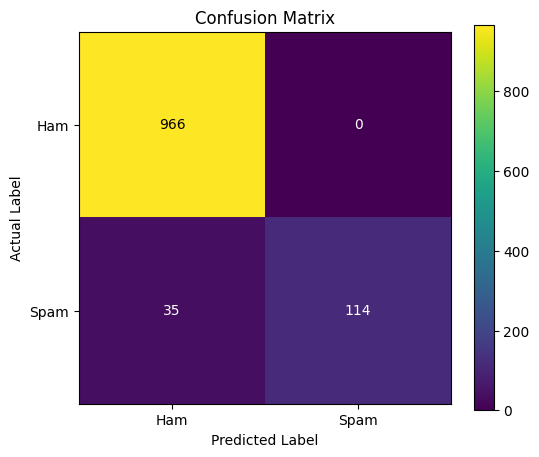

In [ ]:
# ==========================================
# 7. CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="viridis", interpolation="nearest")
plt.colorbar()
plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix")

# Annotate values inside matrix squares
for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="white" if cm[i, j] < 500 else "black")

plt.show()

In [11]:
# ==========================================
# 8. PREDICT A NEW EMAIL MESSAGE
# ==========================================
def predict_email(text):
    prediction = model.predict([text])[0]
    probabilities = model.predict_proba([text])[0]
    confidence = max(probabilities) * 100

    if prediction == 1:
        return f"SPAM EMAIL (Confidence: {confidence:.2f}%)"
    else:
        return f"LEGITIMATE (HAM) EMAIL (Confidence: {confidence:.2f}%)"


# Direct test cases without user input
sample_email_1 = (
    "Congratulations! You have won a $1,000 Walmart Gift Card. Click here to"
    " claim your prize now."
)
print("Email:", sample_email_1)
print("Prediction Result:", predict_email(sample_email_1))

print("-" * 50)

sample_email_2 = (
    "Hey, are we still meeting tomorrow at 10 AM to discuss the project report?"
)
print("Email:", sample_email_2)
print("Prediction Result:", predict_email(sample_email_2))

Email: Congratulations! You have won a $1,000 Walmart Gift Card. Click here to claim your prize now.
Prediction Result: SPAM EMAIL (Confidence: 86.95%)
--------------------------------------------------
Email: Hey, are we still meeting tomorrow at 10 AM to discuss the project report?
Prediction Result: LEGITIMATE (HAM) EMAIL (Confidence: 99.03%)
